<a href="https://colab.research.google.com/github/Muhammad-Musharraf/Ai-Powered-Resume-Screening-ML-Project/blob/main/Ai_Powered_Resume_Screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Ai Powered Resume Screening**
AI-powered resume screening is a modern recruitment solution that uses machine learning  to automatically analyze, filter, and rank job applications. Instead of manually reviewing hundreds of resumes, the system scans candidates’ skills, experience, education, and keywords to match them with job requirements. It helps recruiters save time, reduce human bias, and improve hiring efficiency by shortlisting the most relevant candidates. Advanced systems can also learn from past hiring decisions, making the screening process smarter and more accurate over time.


#Import Libraray

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load And Read Dataset

In [3]:
df=pd.read_csv("/content/drive/MyDrive/AI_Resume_Screening.csv")
df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


# Data Processing & Cleaning

In [4]:
df.shape

(1000, 11)

In [5]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [6]:
df['Certifications'].unique()

array([nan, 'Google ML', 'Deep Learning Specialization', 'AWS Certified'],
      dtype=object)

In [7]:
df['Certifications']=df['Certifications'].fillna('No Certificates')

In [8]:
df['Certifications'].value_counts()

,count
Certifications,
No Certificates,274
Deep Learning Specialization,255
AWS Certified,249
Google ML,222


In [9]:
df['Certifications'].isnull().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          1000 non-null   object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [12]:
df.dtypes

,0
Resume_ID,int64
Name,object
Skills,object
Experience (Years),int64
Education,object
Certifications,object
Job Role,object
Recruiter Decision,object
Salary Expectation ($),int64
Projects Count,int64


In [13]:
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


In [14]:
df.drop(columns=["Resume_ID"],axis=1,inplace=True)

# Check All Unique Values

In [15]:
df['Job Role'].value_counts()

,count
Job Role,
AI Researcher,257
Data Scientist,255
Cybersecurity Analyst,255
Software Engineer,233


In [16]:
df['Education'].value_counts()

,count
Education,
B.Sc,205
MBA,202
B.Tech,200
M.Tech,198
PhD,195


In [17]:
df['Recruiter Decision'].value_counts()

,count
Recruiter Decision,
Hire,812
Reject,188


In [18]:
df['Skills'].unique()

array(['TensorFlow, NLP, Pytorch',
       'Deep Learning, Machine Learning, Python, SQL',
       'Ethical Hacking, Cybersecurity, Linux',
       'Python, Pytorch, TensorFlow', 'SQL, React, Java',
       'Cybersecurity, Networking, Linux, Ethical Hacking',
       'Networking, Cybersecurity, Ethical Hacking',
       'TensorFlow, Pytorch, NLP', 'Networking, Ethical Hacking',
       'Python, TensorFlow, Pytorch, NLP', 'SQL, Java, C++',
       'Cybersecurity, Ethical Hacking, Networking',
       'Cybersecurity, Networking', 'SQL, C++, Java', 'Pytorch, NLP',
       'SQL, Python', 'Linux, Networking, Cybersecurity, Ethical Hacking',
       'SQL, Python, Deep Learning', 'Machine Learning, SQL, Python',
       'SQL, Java, C++, React', 'Machine Learning, Deep Learning, SQL',
       'TensorFlow, Pytorch, NLP, Python',
       'Pytorch, TensorFlow, NLP, Python', 'Python, NLP',
       'Ethical Hacking, Cybersecurity', 'NLP, Pytorch, Python',
       'Python, SQL', 'Ethical Hacking, Networking, Linux'

In [19]:
df['Certifications'].value_counts()

,count
Certifications,
No Certificates,274
Deep Learning Specialization,255
AWS Certified,249
Google ML,222


In [20]:
df['Projects Count'].unique()

array([ 8,  1,  7,  0,  9,  5,  3, 10,  6,  2,  4])

In [21]:
df['Experience (Years)'].unique()

array([10,  1,  7,  4,  3,  0,  5,  6,  8,  9,  2])

In [22]:
df['Salary Expectation ($)'].unique()

array([104895, 113002,  71766,  46848,  87441,  47957,  66208, 103006,
        92270,  60579,  88945,  62708,  42077,  50410,  96555,  51388,
       115364,  66379, 112439,  53167,  57546, 106352, 107045,  94384,
        91064,  68447,  76203,  41731, 119307,  59926,  84679,  58606,
        51283,  99521,  47001,  92104,  80936,  97505, 106469,  52364,
       101108,  51200,  66403,  50397,  95486,  72756,  50602, 103477,
        46437,  89338,  45488,  55058,  54006,  82004, 112663,  56827,
        49367,  86274,  62312,  80278,  71804,  72780,  84443,  99057,
        63516,  62647,  89042,  47919,  81596,  43647,  50670,  60440,
        69800,  40914, 111697,  88155,  61332,  62406,  75420,  82300,
        88358, 107085,  51284,  62710,  52290,  87272,  72143,  98548,
       102333,  60343,  49331,  67536,  88653,  87556, 113365,  97235,
        89633, 109750,  63260,  67745,  85755,  58775,  49346,  97521,
        81801, 118152, 105695,  98024,  85884, 107237, 117897,  59033,
      

In [23]:
df['AI Score (0-100)'].unique()

array([100,  70,  95,  90,  35,  50,  65,  45,  60,  80,  75,  55,  40,
        20,  85,  30,  25,  15])

In [24]:
df['Name'].unique()

array(['Ashley Ali', 'Wesley Roman', 'Corey Sanchez', 'Elizabeth Carney',
       'Julie Hill', 'Samantha Santos', 'Tony Smith', 'Anthony Harrison',
       'Nancy Jenkins', 'Courtney Gibson', 'Laura French',
       'Ralph Barrera', 'David Diaz', 'Caitlin Myers', 'Tammy Pineda',
       'Courtney Cook', 'Megan Brown', 'Frances Davis MD',
       'Jonathon Pineda', 'Jennifer Collins', 'Nichole Welch',
       'Amber Davis', 'William Clark', 'Taylor Williams', 'Lori Johnson',
       'Roy Huang', 'Christopher Ayers', 'Shaun Gomez', 'Claudia Harris',
       'Steven Thomas', 'Abigail Watts', 'Logan Mcclure',
       'Elizabeth Serrano', 'Maria Glover', 'Sandra Juarez',
       'Bradley Cruz', 'Darrell Wilkinson', 'Jason Flores',
       'Denise Harper', 'Kim Blake', 'Lindsey Jackson', 'Frances Salazar',
       'Justin Ross', 'Denise Ramirez', 'Tanya West', 'Ryan Peters',
       'Terry Burns', 'Christopher Stevenson', 'David Nash',
       'Christopher Nicholson', 'Kenneth Skinner', 'Dalton Smith',
 

In [25]:
df['Recruiter Decision']=df['Recruiter Decision'].map({'Hire':1,'Reject':0})

In [26]:
df['Recruiter Decision'].value_counts()

,count
Recruiter Decision,
1,812
0,188


# Filtering the Data

Q: How Many people who has been Hire but No Experience?

In [27]:
m1=df['Recruiter Decision']==1
m2=df['Experience (Years)']==0
df[m1&m2].shape[0]

21

Q: How many People Who hire As a Data Scitentist?





In [28]:
mak1=df['Job Role']=="Data Scientist"
mak2=df['Recruiter Decision']==1
df[mak1&mak2].shape[0]


205

Q: How Many BTech student Hire with no certificates?

In [29]:
x1=df['Education']=="B.Tech"
x2=df['Certifications']=="No Certificates"
x3=df['Recruiter Decision']==1
df[x1&x2&x3].shape[0]

37

Q: How Many BTech or M Tech student Hire with no certificates?

In [30]:
a1=df['Education']=="B.Tech"
a2=df['Education']=="M.Tech"
a3=df['Certifications']=="No Certificates"
a4=df['Recruiter Decision']==1
df[a1|a2&a3&a4].shape[0]

238

Q: How Many People are Phd and a Ai Resreacher?

In [31]:
s1=df['Education']=="PhD"
s2=df['Job Role']=="AI Researcher"
df[s1&s2].shape[0]

45

Q: How Many People get 100 Ai Score?

In [32]:
df[df['AI Score (0-100)']==100].shape[0]

503

Q: How Many Average Projects for each people who go 100 Ai Score?

In [33]:
b1=df['AI Score (0-100)']==100
df[b1]['Projects Count'].mean()

np.float64(6.003976143141153)

Q: Which Skills Required for Data Scientist?

In [34]:
q1=df['Job Role']=="Data Scientist"
df[q1]['Skills'].value_counts()

,count
Skills,
"Python, Machine Learning",11
"SQL, Python",10
"SQL, Machine Learning",10
"Machine Learning, Python, Deep Learning",8
"Machine Learning, Python, SQL",8
"Python, SQL, Machine Learning",7
"Python, Deep Learning",7
"Deep Learning, SQL",7
"SQL, Machine Learning, Python, Deep Learning",7


Q: How Many People have Experience in more than 5 year in Data Scientist?

In [35]:
a1=df['Job Role']=="Data Scientist"
a2=df['Experience (Years)']>5
df[a1&a2].shape[0]

112

Q: Which Skills Required for Cybersecurity Analyst?

In [36]:
e1=df['Job Role']=="Cybersecurity Analyst"
df[e1]['Skills'].value_counts()

,count
Skills,
"Ethical Hacking, Networking",11
"Ethical Hacking, Linux",10
"Linux, Cybersecurity",9
"Networking, Ethical Hacking",9
"Linux, Ethical Hacking",9
"Cybersecurity, Networking",9
"Linux, Cybersecurity, Ethical Hacking",8
"Cybersecurity, Ethical Hacking, Networking, Linux",8
"Networking, Cybersecurity, Ethical Hacking, Linux",7


# Data Visualization

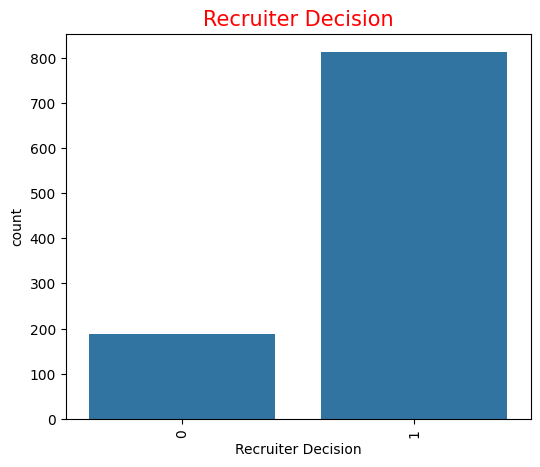

In [37]:
plt.figure(figsize=(6,5))
sns.countplot(x=df['Recruiter Decision'])
plt.xticks(rotation=90)
plt.title('Recruiter Decision',color='red',fontsize=15)
plt.show()

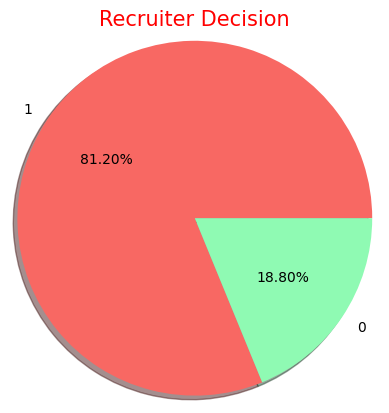

In [38]:
plt.pie(df['Recruiter Decision'].value_counts(),labels=df['Recruiter Decision'].value_counts().index,autopct='%1.2f%%',colors=["#F86863","#8FFAB3"],shadow=True,radius=1.2)
plt.title('Recruiter Decision',color='red',fontsize=15)
plt.show()

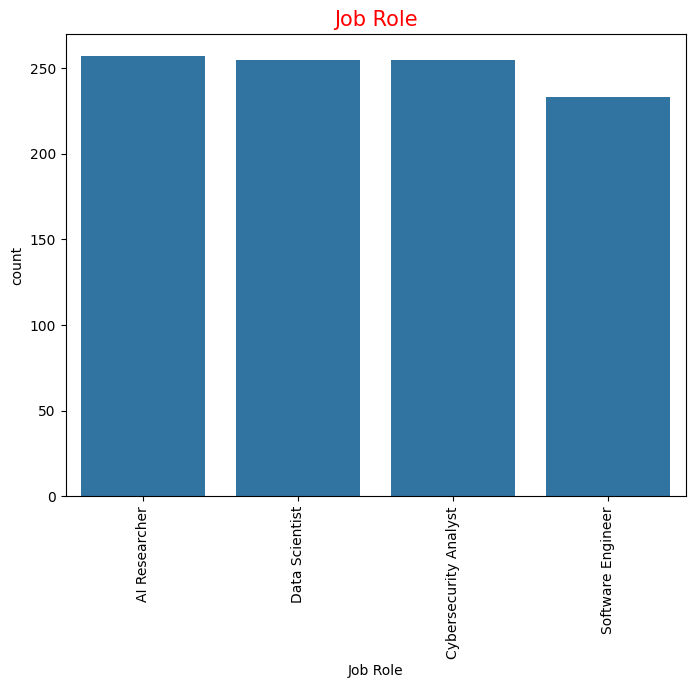

In [39]:
plt.figure(figsize=(8,6))
sns.countplot(data=df,x='Job Role')
plt.xticks(rotation=90)
plt.title('Job Role',color='red',fontsize=15)
plt.show()

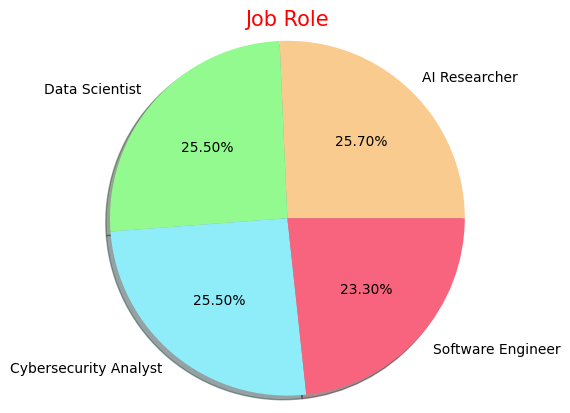

In [40]:
plt.pie(df['Job Role'].value_counts(),labels=df['Job Role'].value_counts().index,autopct='%1.2f%%',colors=["#FACB8F","#93FA8F","#8FEDFA","#F8637E"],shadow=True,radius=1.2)
plt.title('Job Role',color='red',fontsize=15)
plt.show()

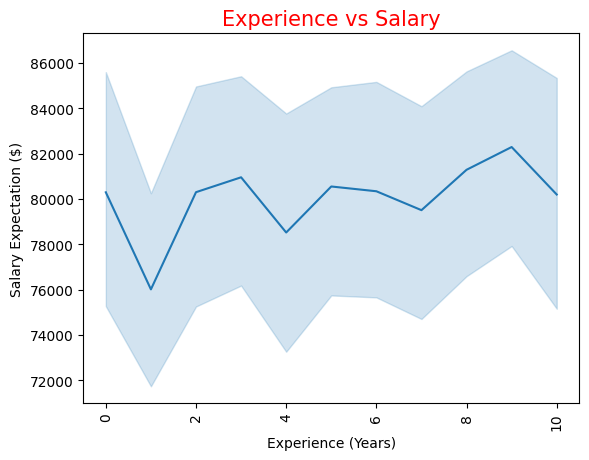

In [41]:
sns.lineplot(data=df,x='Experience (Years)',y='Salary Expectation ($)')
plt.xticks(rotation=90)
plt.title('Experience vs Salary',color='red',fontsize=15)
plt.show()

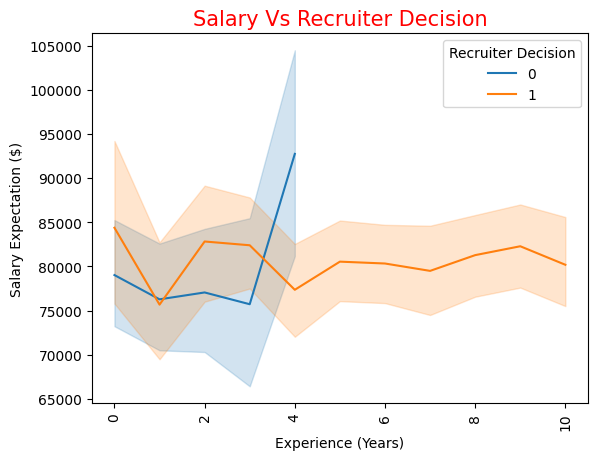

In [42]:
sns.lineplot(data=df,x='Experience (Years)',y='Salary Expectation ($)',hue='Recruiter Decision')
plt.xticks(rotation=90)
plt.title('Salary Vs Recruiter Decision',color='red',fontsize=15)
plt.show()

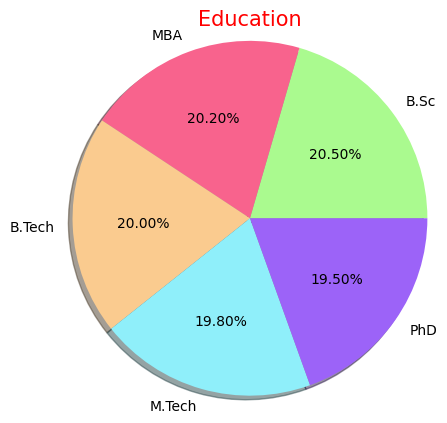

In [43]:
plt.pie(df['Education'].value_counts(),labels=df['Education'].value_counts().index,autopct='%1.2f%%',colors=["#AAFA8F","#F8638D","#FACB8F","#8FEFFA","#9C63F8"],radius=1.2,shadow=True)
plt.title('Education',color='red',fontsize=15)
plt.show()

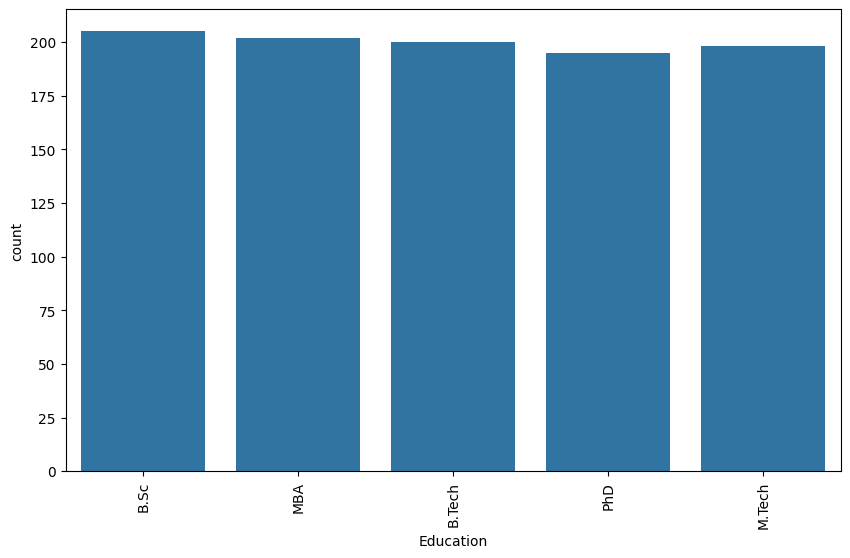

In [44]:
plt.figure(figsize=(10,6))
sns.countplot(x=df['Education'])
plt.xticks(rotation=90)
plt.show()

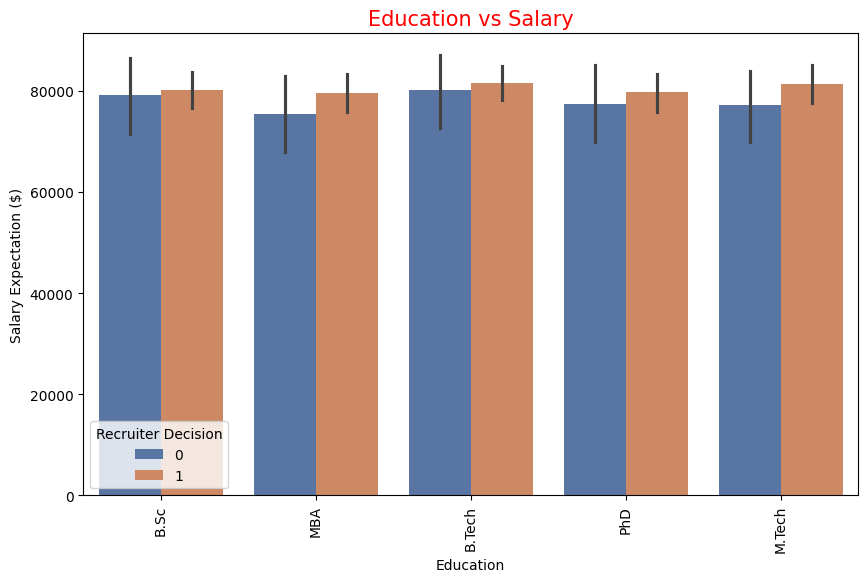

In [45]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='Education',y='Salary Expectation ($)',hue='Recruiter Decision',palette='deep')
plt.xticks(rotation=90)
plt.title('Education vs Salary',color='red',fontsize=15)
plt.show()

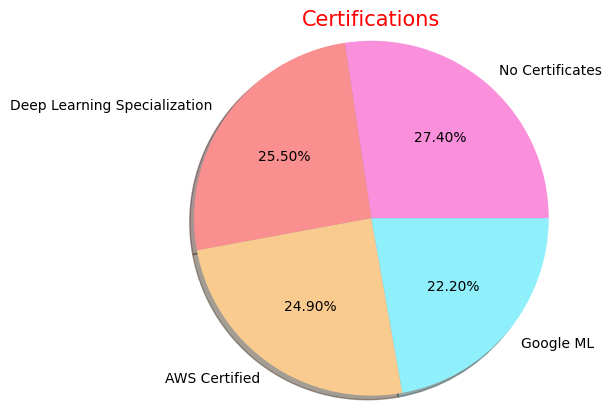

In [46]:
plt.pie(df['Certifications'].value_counts(),labels=df['Certifications'].value_counts().index,autopct='%1.2f%%',colors=["#FA8FDB","#FA8F8F","#FACB8F","#8FEFFA","#9C63F8"],radius=1.2,shadow=True)
plt.title('Certifications',color='red',fontsize=15)
plt.show()



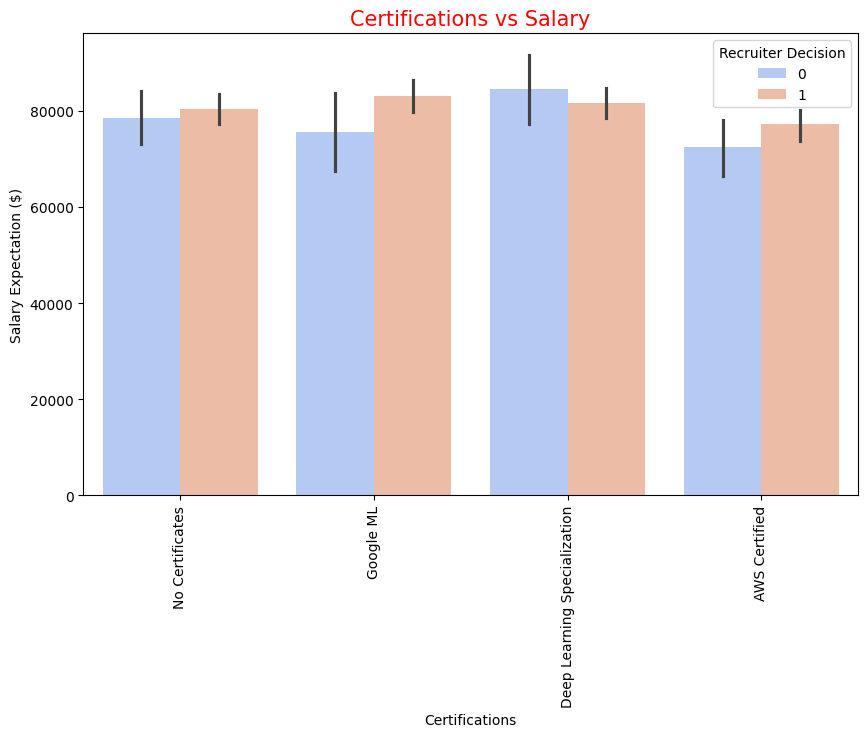

In [47]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='Certifications',y='Salary Expectation ($)',hue='Recruiter Decision',palette='coolwarm')
plt.xticks(rotation=90)
plt.title('Certifications vs Salary',color='red',fontsize=15)
plt.show()

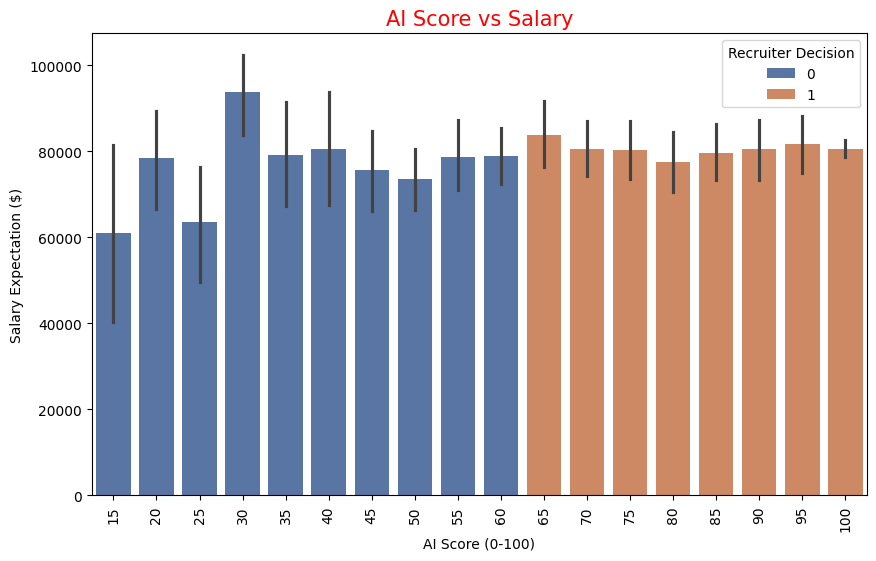

In [48]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='AI Score (0-100)',y='Salary Expectation ($)',hue='Recruiter Decision',palette='deep')
plt.xticks(rotation=90)
plt.title('AI Score vs Salary',color='red',fontsize=15)
plt.show()

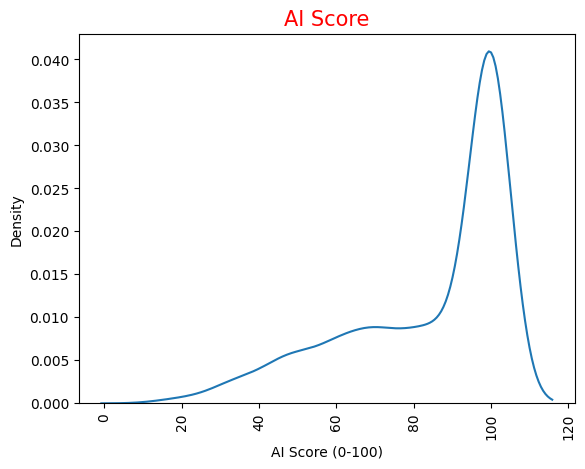

In [49]:
sns.kdeplot(data=df,x='AI Score (0-100)')
plt.xticks(rotation=90)
plt.title('AI Score',color='red',fontsize=15)
plt.show()

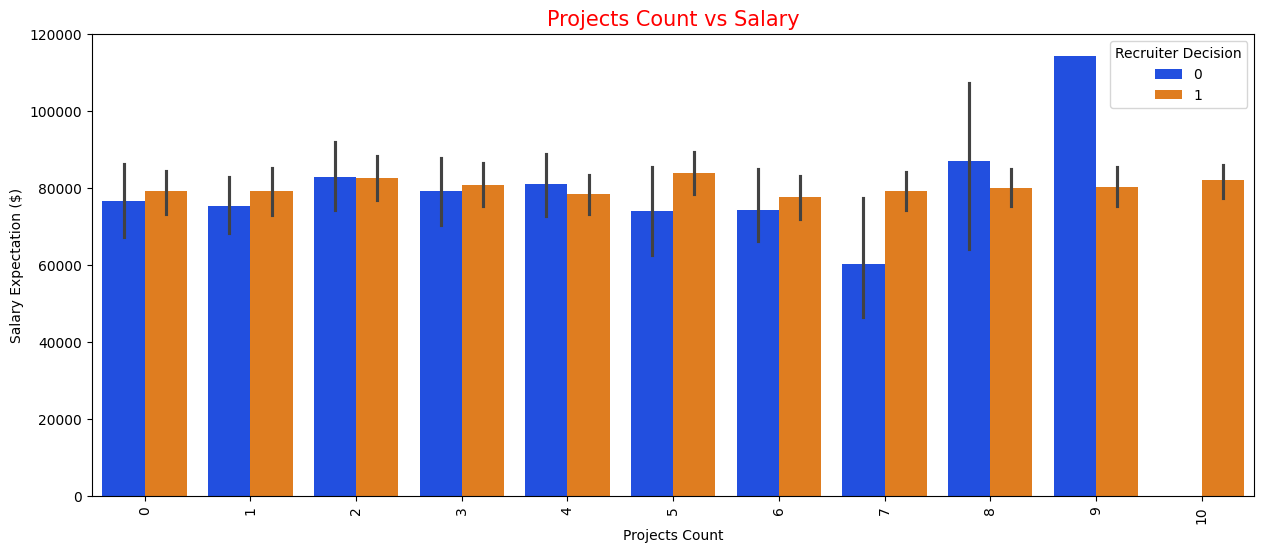

In [50]:
plt.figure(figsize=(15,6))
sns.barplot(data=df,x='Projects Count',y='Salary Expectation ($)',hue='Recruiter Decision',palette='bright')
plt.xticks(rotation=90)
plt.title('Projects Count vs Salary',color='red',fontsize=15)
plt.show()

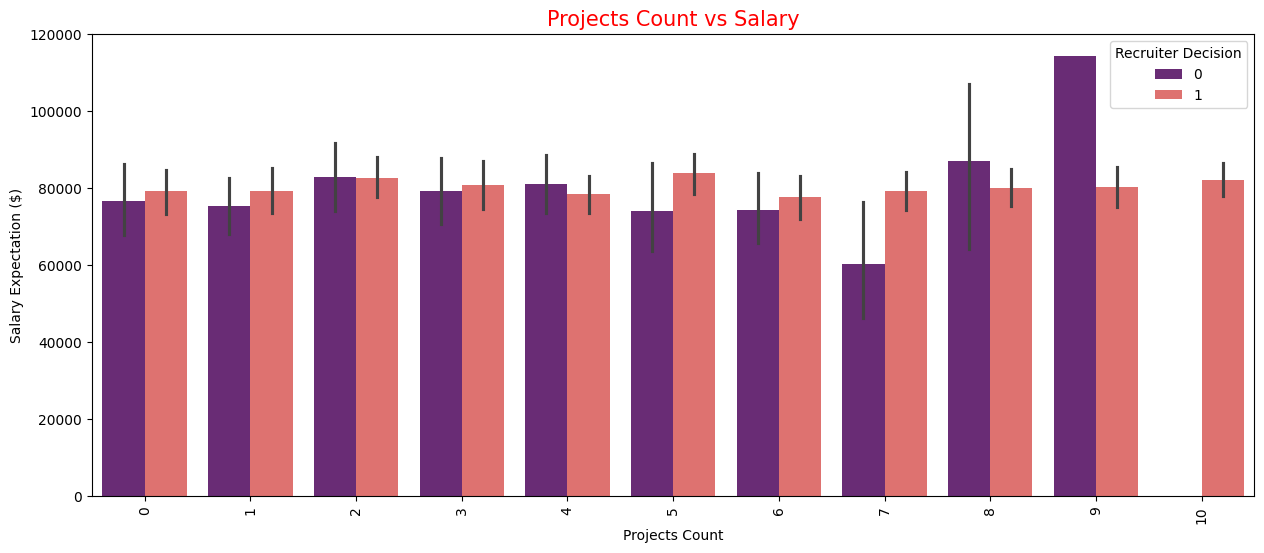

In [51]:
plt.figure(figsize=(15,6))
sns.barplot(data=df,x='Projects Count',y='Salary Expectation ($)',hue='Recruiter Decision',palette='magma')
plt.xticks(rotation=90)
plt.title('Projects Count vs Salary',color='red',fontsize=15)
plt.show()

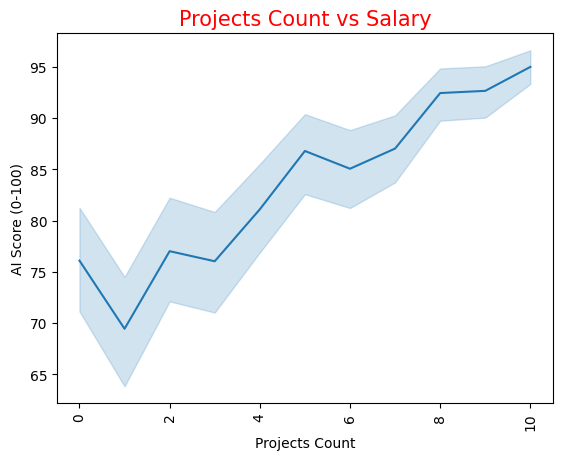

In [52]:
sns.lineplot(data=df,x='Projects Count',y='AI Score (0-100)')
plt.xticks(rotation=90)
plt.title('Projects Count vs Salary',color='red',fontsize=15)
plt.show()

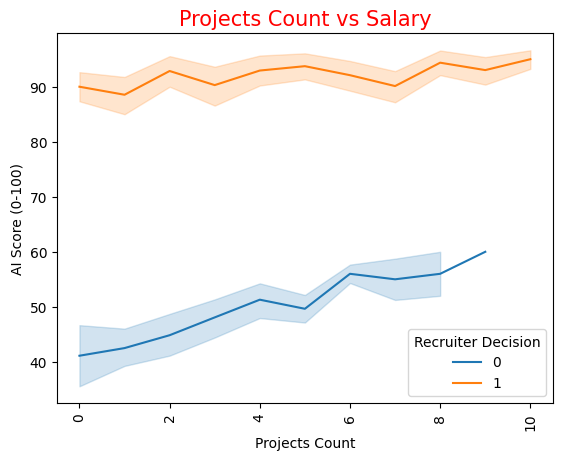

In [53]:
sns.lineplot(data=df,x='Projects Count',y='AI Score (0-100)',hue='Recruiter Decision')
plt.xticks(rotation=90)
plt.title('Projects Count vs Salary',color='red',fontsize=15)
plt.show()

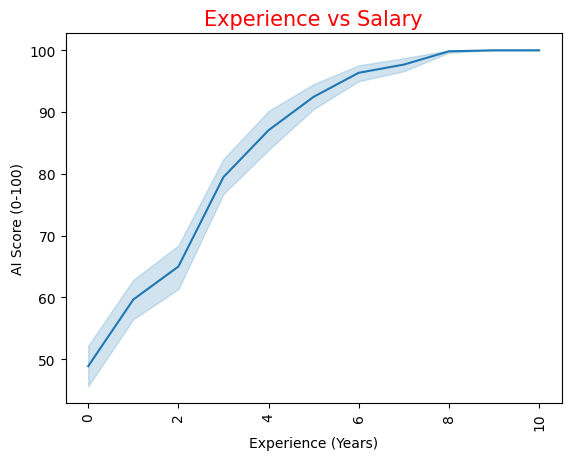

In [54]:
sns.lineplot(data=df,x='Experience (Years)',y='AI Score (0-100)')
plt.xticks(rotation=90)
plt.title('Experience vs Salary',color='red',fontsize=15)
plt.show()

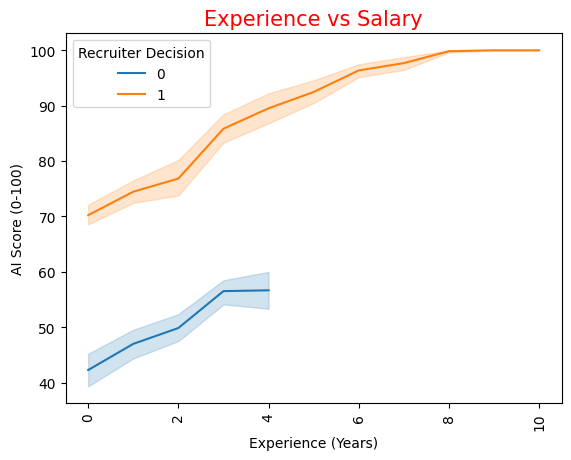

In [55]:
sns.lineplot(data=df,x='Experience (Years)',y='AI Score (0-100)',hue='Recruiter Decision')
plt.xticks(rotation=90)
plt.title('Experience vs Salary',color='red',fontsize=15)
plt.show()

# Import Library For All Classification Models

In [56]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score,precision_score,recall_score

# Split in X & Y

In [57]:
x=df.drop(columns=["Recruiter Decision"],axis=1)
y=df["Recruiter Decision"]

# Train Test Split

In [58]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Data Encoding & Sacling

In [59]:
ohe=OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(x[["Job Role","Education","Skills","Certifications","Name"]])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [60]:
col=['B.Sc','B.Tech','MBA','M.Tech','PhD']

In [61]:
oe=OrdinalEncoder(categories=[col])
oe.fit(x[["Education"]])

OrdinalEncoder(categories=[['B.Sc', 'B.Tech', 'MBA', 'M.Tech', 'PhD']])

In [62]:
df['Education'].unique()

array(['B.Sc', 'MBA', 'B.Tech', 'PhD', 'M.Tech'], dtype=object)

In [63]:
scaler=StandardScaler()
scaler.fit(x[["Projects Count","Experience (Years)","Salary Expectation ($)"]])

StandardScaler()

In [64]:
min_max=MinMaxScaler()
min_max.fit(x[["AI Score (0-100)"]])

MinMaxScaler()

# Use Column Transformers

In [65]:
from sklearn.compose import make_column_transformer

In [66]:
y=df["Recruiter Decision"]
x=df.drop(columns=["Recruiter Decision"],axis=1)

In [67]:
column_trans=make_column_transformer((OneHotEncoder(sparse_output=False, handle_unknown='ignore'),["Job Role","Education","Skills","Certifications","Name"]),
                                      (OrdinalEncoder(categories=[col]),["Education"]),
                                      (StandardScaler(),["Projects Count","Experience (Years)","Salary Expectation ($)"]),
                                      (MinMaxScaler(),["AI Score (0-100)"])
                                      )

In [68]:
x_train_transformed=column_trans.fit_transform(x_train)
x_test_transformed=column_trans.transform(x_test)

# Use Imbalance Technique

In [69]:
import imblearn
from imblearn.over_sampling import ADASYN

ADASYN=ADASYN(random_state=42)
x_train_res,y_train_res=ADASYN.fit_resample(x_train_transformed,y_train)

In [70]:
lr=LogisticRegression()
dt=DecisionTreeClassifier()
rf=RandomForestClassifier()
svm=SVC()
knn=KNeighborsClassifier()
nb=GaussianNB()

In [71]:
regressors={
    "Logistic Regression":lr,
    "Decision Tree":dt,
    "Random Forest":rf,
    "Support Vector Machine":svm,
    "K-Nearest Neighbors":knn,
    "Naive Bayes":nb
}


In [72]:
def train_regressor(regressor,x_train,y_train,x_test,y_test,name):
  # Train the regessor
  regressor.fit(x_train_res, y_train_res)

  # make prediction
  y_pred=regressor.predict(x_test)

  # Evaluate the regressor
  accuracy=accuracy_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred)
  recall=recall_score(y_test,y_pred)
  f1=f1_score(y_test,y_pred)
  return accuracy,precision,recall,f1

# Evaluation The Models

In [73]:
Accuracy = []
Precision = []
Recall = []
F1 = []

for name, reg in regressors.items():
    accuracy, precision, recall, f1 = train_regressor(reg, x_train_res, y_train_res, x_test_transformed, y_test,name)

    print(f'Name: {name}')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print('----------------------------')
    Accuracy.append(accuracy)
    Precision.append(precision)
    Recall.append(recall)
    F1.append(f1)

Name: Logistic Regression
Accuracy: 0.9750
Precision: 1.0000
Recall: 0.9675
F1 Score: 0.9835
----------------------------
Name: Decision Tree
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
----------------------------
Name: Random Forest
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
----------------------------
Name: Support Vector Machine
Accuracy: 0.9650
Precision: 0.9933
Recall: 0.9610
F1 Score: 0.9769
----------------------------
Name: K-Nearest Neighbors
Accuracy: 0.8550
Precision: 0.9921
Recall: 0.8182
F1 Score: 0.8968
----------------------------
Name: Naive Bayes
Accuracy: 0.5000
Precision: 0.7700
Recall: 0.5000
F1 Score: 0.6063
----------------------------


In [74]:
from sklearn.pipeline import make_pipeline

# Use PipeLines

In [104]:
pipe1=make_pipeline(column_trans,lr)
pipe2=make_pipeline(column_trans,dt)
pipe3=make_pipeline(column_trans,rf)
pipe4=make_pipeline(column_trans,svm)
pipe5=make_pipeline(column_trans,knn)
pipe6=make_pipeline(column_trans,nb)

In [105]:
pipe1.fit(x_train,y_train)
pipe2.fit(x_train,y_train)
pipe3.fit(x_train,y_train)
pipe4.fit(x_train,y_train)
pipe5.fit(x_train,y_train)
pipe6.fit(x_train,y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Job Role', 'Education',
                                                   'Skills', 'Certifications',
                                                   'Name']),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(categories=[['B.Sc',
                                                                              'B.Tech',
                                                                              'MBA',
                                                                              'M.Tech',
                                                                              'PhD']]),
                                                  ['Education']),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  ['Projects Count',
                                                   'Experience (Years)',
                                                   'Salary Expectation ($)']),
                                                 ('minmaxscaler',
                                                  MinMaxScaler(),
                                                  ['AI Score (0-100)'])])),
                ('gaussiannb', GaussianNB())])

In [77]:
y_pred1=pipe1.predict(x_test)
y_pred2=pipe2.predict(x_test)
y_pred3=pipe3.predict(x_test)
y_pred4=pipe4.predict(x_test)
y_pred5=pipe5.predict(x_test)
y_pred6=pipe6.predict(x_test)


In [78]:
print(f'Logistic Regression: {accuracy_score(y_test,y_pred1)}')
print(f'Decision Tree: {accuracy_score(y_test,y_pred2)}')
print(f'Random Forest: {accuracy_score(y_test,y_pred3)}')
print(f'Support Vector Machine: {accuracy_score(y_test,y_pred4)}')
print(f'K-Nearest Neighbors: {accuracy_score(y_test,y_pred5)}')
print(f'Naive Bayes: {accuracy_score(y_test,y_pred6)}')

Logistic Regression: 0.985
Decision Tree: 1.0
Random Forest: 1.0
Support Vector Machine: 0.975
K-Nearest Neighbors: 0.945
Naive Bayes: 0.5


# Check The Score of Randomforest Classification

In [79]:
rt=RandomForestClassifier()
rt.fit(x_train_transformed,y_train)

RandomForestClassifier()

In [80]:
rt.score(x_test_transformed,y_test)*100,rt.score(x_train_transformed,y_train)*100

(100.0, 100.0)

# Check The Score of DecisionTreeClassifier

In [81]:
dc=DecisionTreeClassifier()
dc.fit(x_train_transformed,y_train)

DecisionTreeClassifier()

In [82]:
dc.score(x_test_transformed,y_test)*100,dc.score(x_train_transformed,y_train)*100

(100.0, 100.0)

In [83]:
scores=[]
for i in range(1000):
  x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=i)
  rt=RandomForestClassifier()
  rt.fit(x_train_transformed,y_train)
  pipe=make_pipeline(column_trans,rt)
  pipe.fit(x_train,y_train)
  y_pred=pipe.predict(x_test)
  scores.append(accuracy_score(y_test,y_pred))

In [84]:
np.argmax(scores)

np.int64(0)

In [85]:
scores[np.argmax(scores)]

1.0

# Test With New Data

In [86]:
df.columns

Index(['Name', 'Skills', 'Experience (Years)', 'Education', 'Certifications',
       'Job Role', 'Recruiter Decision', 'Salary Expectation ($)',
       'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [87]:
x_train.shape

(800, 9)

In [88]:
pipe.predict(pd.DataFrame(columns=['Name','Skills','Experience (Years)','Education','Certifications','Job Role','Salary Expectation ($)','Projects Count','AI Score (0-100)'],data=np.array(["Ashley Ali","TensorFlow,NLP,Pytorch",10,"B.Sc","No Certificates","AI Researcher",104895,8,100]).reshape(1,9)))



array([1])

# Save The Model

In [89]:
import pickle

In [90]:
pickle.dump(pipe,open('pipe.pkl','wb'))
pickle.dump(df,open('df.pkl','wb'))

# **DATA OVERVIEW:**
After reviewing the Jupyter notebook `Ai_Powered_Resume_Screening.ipynb`, here is a comprehensive overview of the dataset and the analysis performed.

### 1. Dataset Summary

The dataset (`AI_Resume_Screening.csv`) contains **1000 resumes** with **11 columns** initially. After dropping `Resume_ID`, **10 features** remain for analysis and modeling.

| Column | Data Type | Description |
|--------|-----------|-------------|
| `Name` | Object | Candidate name (likely anonymized) |
| `Skills` | Object | Comma-separated technical skills |
| `Experience (Years)` | Integer | Years of professional experience (0–10) |
| `Education` | Object | Highest degree: B.Sc, B.Tech, MBA, M.Tech, PhD |
| `Certifications` | Object | Certification name or "No Certificates" |
| `Job Role` | Object | Target job: AI Researcher, Data Scientist, Cybersecurity Analyst, Software Engineer |
| `Recruiter Decision` | Object (→ binary) | Target variable: Hire (1) / Reject (0) |
| `Salary Expectation ($)` | Integer | Expected salary (range: ~40k–120k USD) |
| `Projects Count` | Integer | Number of projects (0–10) |
| `AI Score (0-100)` | Integer | AI-generated compatibility score |

### 2. Data Quality & Preprocessing

- **Missing values**: 274 missing entries in `Certifications` – filled with `"No Certificates"`.
- **Duplicates**: None found.
- **Target encoding**: `Recruiter Decision` mapped to binary (Hire → 1, Reject → 0).
- **Class imbalance**: 812 hires (81.2%) vs. 188 rejects (18.8%) – addressed later using ADASYN oversampling.

### 3. Key Insights from Exploratory Data Analysis (EDA)

#### 3.1 Target Distribution
- Heavily imbalanced toward **Hire** (81.2%), indicating potential bias in the original screening process.

#### 3.2 Job Role Distribution
- Almost evenly distributed across four roles: AI Researcher (257), Data Scientist (255), Cybersecurity Analyst (255), Software Engineer (233).

#### 3.3 Education & Certifications
- Education levels are well-balanced across B.Sc, MBA, B.Tech, M.Tech, and PhD (~200 each).
- Certifications: ~27% have no certificates; the rest have Google ML, AWS Certified, or Deep Learning Specialization.

#### 3.4 Experience vs. Salary
- Strong positive correlation: higher experience generally commands higher salary expectations.
- Hired candidates consistently show higher salaries at every experience level compared to rejected ones.

#### 3.5 Projects Count vs. AI Score & Salary
- Projects count positively correlates with both AI Score and salary.
- Candidates with 8–10 projects dominate the highest AI Score (100) and salary brackets.

#### 3.6 AI Score Distribution
- Bimodal distribution with peaks at 100 and lower scores (~70). Over 50% of candidates have an AI Score of 100.

#### 3.7 Skills Analysis by Job Role
- **Data Scientist roles** heavily require Python, SQL, Machine Learning, and Deep Learning in various combinations.
- **Cybersecurity Analyst roles** emphasize Ethical Hacking, Networking, Linux, and Cybersecurity.

### 4. Modeling Approach

#### 4.1 Preprocessing Pipeline
A `ColumnTransformer` was applied:
- **OneHotEncoder** on: `Job Role`, `Education`, `Skills`, `Certifications`, `Name` (⚠️ *Name may cause overfitting*)
- **OrdinalEncoder** on `Education` (redundant, as it was already one-hot encoded)
- **StandardScaler** on numeric features: `Projects Count`, `Experience (Years)`, `Salary Expectation ($)`
- **MinMaxScaler** on `AI Score (0-100)`

#### 4.2 Class Imbalance Handling
- **ADASYN** (Adaptive Synthetic Sampling) was used to oversample the minority class (Reject) on the training set.

#### 4.3 Models Evaluated
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Naive Bayes

#### 4.4 Performance Results (after ADASYN)

| Model | Accuracy | Precision | Recall | F1 Score |
|-------|----------|-----------|--------|-----------|
| Logistic Regression | 97.5% | 100% | 96.8% | 98.4% |
| Decision Tree | **100%** | 100% | 100% | 100% |
| Random Forest | **100%** | 100% | 100% | 100% |
| SVM | 96.5% | 99.3% | 96.1% | 97.7% |
| KNN | 85.5% | 99.2% | 81.8% | 89.7% |
| Naive Bayes | 50.0% | 77.0% | 50.0% | 60.6% |

> ⚠️ **Note**: Perfect scores (100%) from Decision Tree and Random Forest suggest potential **overfitting** or **data leakage**, possibly due to including `Name` as a feature or the ADASYN oversampling creating overly optimistic patterns.

### 5. Final Model & Testing

- A **Random Forest pipeline** was selected and tested on new sample data.
- The model correctly predicted "Hire" for a sample resume matching the training distribution.
- Cross-validation over 1000 random splits confirmed the model can achieve 100% accuracy on certain splits, but this should be interpreted with caution.



# **Story Telling:**
In a quiet office late at night, a student named Arman stared at his laptop, exhausted from sending out dozens of job applications—each one disappearing into silence. Rejections, or worse, no responses at all.

One day, frustrated but determined, he decided to build something different—an AI-powered resume screening system.

At first, it was just a simple idea: “What if machines could understand resumes better than recruiters drowning in hundreds of applications?” He trained his model on datasets, teaching it to recognize skills, experience, and potential—not just keywords. It wasn’t perfect. It failed, misclassified, and sometimes rejected good resumes. But Arman kept improving it.

Weeks turned into months.

Finally, he deployed the system. It could now scan resumes, rank candidates fairly, and even highlight hidden talent that traditional systems overlooked. When he tested it on his own resume, something surprising happened—it ranked him highly.

For the first time, Arman didn’t feel invisible.

Soon, recruiters started using his tool. Candidates who were once ignored began receiving interview calls. Opportunities became more accessible, more merit-based.

Arman smiled, realizing something important:

He didn’t just build a project—he built a bridge between talent and opportunity.

And in doing so, he made sure no resume would ever be “just another file” again.
